In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

In [3]:
import matplotlib.pyplot as plt

## Download train, validation and test dataframes

In [4]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [5]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [6]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [7]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [8]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df         = df
        self.images_dir = images_dir
        self.transform  = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img


        return img, torch.tensor(label, dtype=torch.long)
    def __len__(self):
        return len(self.df)


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


# ── Datasets ──────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=test_transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 128, 128]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  0,   7,   9,  12,  14,  22,  24,  28,  38,  44,  46,  56,  59,  64,
         69,  70,  71,  73,  75,  76,  77,  80,  81,  88,  98, 103, 109, 115,
        117, 118, 119, 122, 128, 137, 140, 143, 147, 149, 152, 161, 166, 167,
        169, 171, 175, 177, 178, 179, 182, 185, 186, 189, 196])


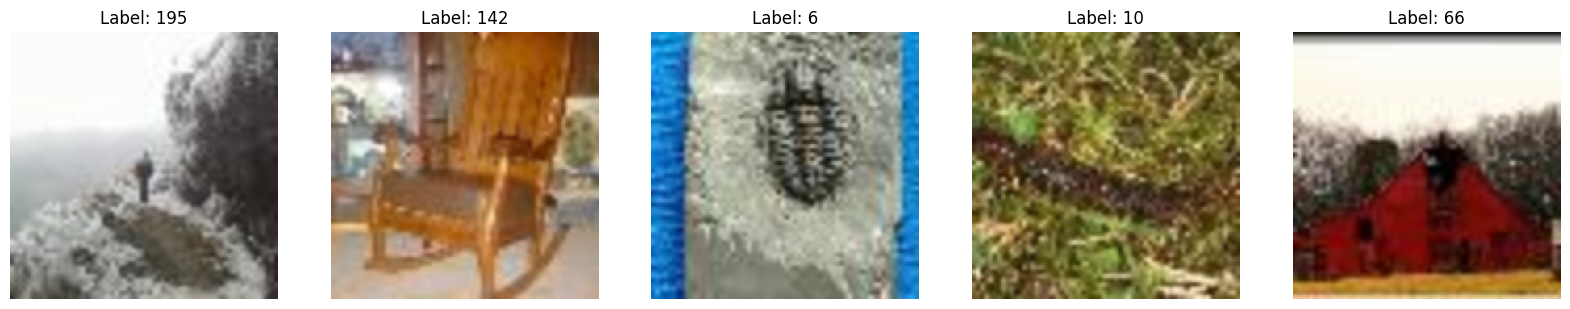

In [10]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

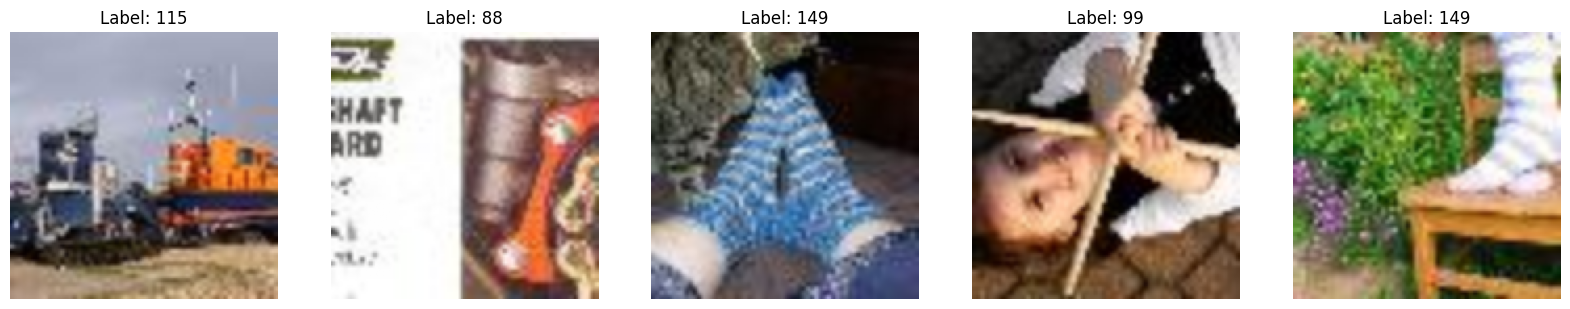

In [11]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

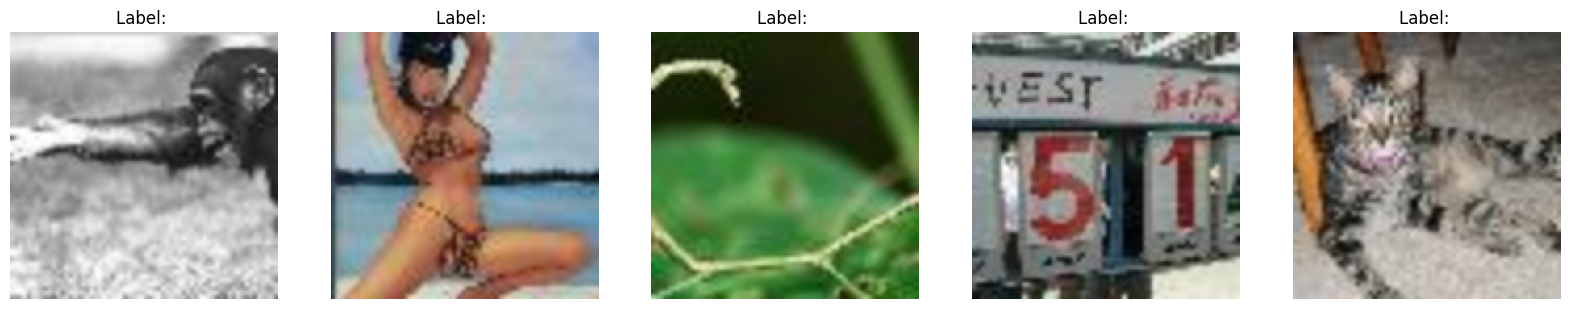

In [12]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:

 ```python
 import torch
 import pandas as pd

 model.eval()
 filenames   = test_dataset.df["File"].tolist()
 predictions = []

 with torch.inference_mode():
     for i, images in enumerate(test_loader):
         images  = images.to(device)
         logits  = model(images)
         preds   = logits.argmax(dim=1).cpu().tolist()
         predictions.extend(preds)

 submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
 submission.to_csv("submission.csv", index=False)
 print(submission.head())
 ```

 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

In [13]:
# ==========================================
# BLOQUE 1 — Importar librerías
# ==========================================

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [16]:
# ==========================================
# BLOQUE 2 — Cargar CSV con verificación
# ==========================================

import os
import pandas as pd

print("Archivos disponibles:")
print(os.listdir())

required_files = ["train.csv", "val.csv", "test.csv"]

missing_files = [f for f in required_files if not os.path.exists(f)]

if len(missing_files) > 0:
    raise FileNotFoundError(
        f"Faltan estos archivos en la carpeta actual: {missing_files}. "
        "Súbelos manualmente o créalos antes de correr este bloque."
    )

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())

Archivos disponibles:
['.virtual_documents']


FileNotFoundError: Faltan estos archivos en la carpeta actual: ['train.csv', 'val.csv', 'test.csv']. Súbelos manualmente o créalos antes de correr este bloque.